## E-Commerce 360° Analytics — Exploratory Data Analysis (EDA)

### Objective

This notebook explores the cleaned Olist e-commerce datasets to identify business patterns, customer behavior, sales trends, product performance, payment preferences, and review insights.

The analysis uses the cleaned datasets generated in **02_data_cleaning.ipynb**.

### EDA Workflow

1. Import libraries
2. Load cleaned datasets
3. Dataset overview
4. Order analysis
5. Customer analysis
6. Sales analysis
7. Payment analysis
8. Product analysis
9. Review analysis
10. Business insights summary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
# Define processed data path
processed_path = Path("../data/processed")

# Load all cleaned CSV files
csv_files = sorted(processed_path.glob("*.csv"))

eda_data = {}

for file in csv_files:
    name = file.stem
    eda_data[name] = pd.read_csv(file)

print(f"Datasets loaded: {len(eda_data)}")

Datasets loaded: 10


In [3]:
overview = pd.DataFrame([
    {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    }
    for name, df in eda_data.items()
])

overview

,Dataset,Rows,Columns
0,customers,99441,5
1,data_cleaning_summary,9,5
2,geolocation,738332,5
3,order_items,112650,7
4,order_payments,103886,5
5,order_reviews,99224,7
6,orders,99441,8
7,product_category_name_translation,71,2
8,products,32951,9
9,sellers,3095,4


In [4]:
# Remove the cleaning summary from EDA datasets
eda_data.pop("data_cleaning_summary", None)

print(f"Analytical datasets available: {len(eda_data)}")

for name, df in eda_data.items():
    print(f"{name}: {df.shape}")

Analytical datasets available: 9
customers: (99441, 5)
geolocation: (738332, 5)
order_items: (112650, 7)
order_payments: (103886, 5)
order_reviews: (99224, 7)
orders: (99441, 8)
product_category_name_translation: (71, 2)
products: (32951, 9)
sellers: (3095, 4)


In [26]:
customers = eda_data["customers"]
geolocation = eda_data["geolocation"]
order_items = eda_data["order_items"]
order_payments = eda_data["order_payments"]
order_reviews = eda_data["order_reviews"]
orders = eda_data["orders"]
products = eda_data["products"]
sellers = eda_data["sellers"]
category_translation = eda_data["product_category_name_translation"]

print("Dataset references created successfully.")

Dataset references created successfully.


## 2.1 Order Status Analysis

### What are we analyzing?

We analyze the distribution of orders across different order statuses such as delivered, canceled, shipped, unavailable, and other statuses.

### Why are we analyzing it?

Order status helps us understand the overall operational outcome of customer orders.

### Business Questions

- What percentage of orders were successfully delivered?
- How many orders were canceled or unavailable?
- What is the overall order fulfillment performance?

### Expected Output

- Order count by status
- Order status percentage
- Order status visualization

These results will help us understand the overall health of the e-commerce order process.

In [27]:
# Step 2.1.1 — Order Status Count

order_status_counts = orders["order_status"].value_counts()

order_status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [28]:
# Step 2.1.2 — Order Status Percentage

order_status_percentage = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

order_status_percentage.columns = [
    "order_status",
    "percentage"
]

order_status_percentage

,order_status,percentage
0,delivered,97.02
1,shipped,1.11
2,canceled,0.63
3,unavailable,0.61
4,invoiced,0.32
5,processing,0.30
6,created,0.01
7,approved,0.00


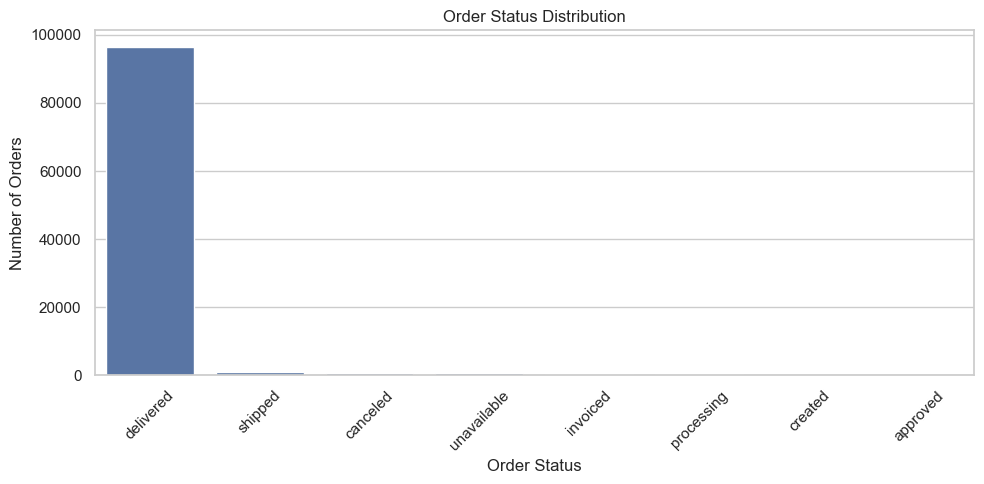

In [29]:
# Step 2.1.3 — Order Status Visualization

plt.figure(figsize=(10, 5))

sns.countplot(
    data=orders,
    x="order_status",
    order=orders["order_status"].value_counts().index
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 2.2 Monthly Order Trend

### What are we analyzing?

We analyze how the number of orders changes month by month over the available period.

### Why are we analyzing it?

Monthly order trends help identify business growth, decline, seasonal patterns, and high-demand periods.

### Business Questions

- How does order volume change over time?
- Which months have the highest order volume?
- Are there noticeable growth or seasonal patterns?

### Expected Output

- Monthly order count
- Monthly order trend visualization
- Top 10 months by order volume

In [30]:
# Step 2.2.1 — Convert Order Purchase Date

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

In [31]:
# Step 2.2.2 — Calculate Monthly Orders

monthly_orders = (
    orders
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
    .reset_index(name="order_count")
)

monthly_orders.head()

,order_purchase_timestamp,order_count
0,2016-09-30,4
1,2016-10-31,324
2,2016-11-30,0
3,2016-12-31,1
4,2017-01-31,800


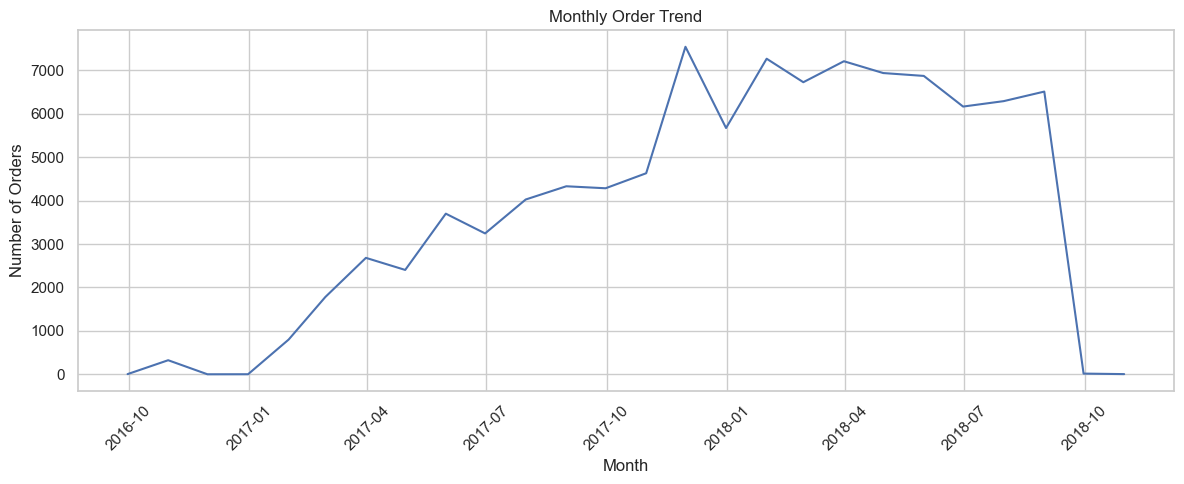

In [32]:
# Step 2.2.3 — Visualize Monthly Orders

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_orders["order_purchase_timestamp"],
    monthly_orders["order_count"]
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
# Step 2.2.4 — Top 10 Order Months

top_order_months = (
    monthly_orders
    .sort_values("order_count", ascending=False)
    .head(10)
)

top_order_months

,order_purchase_timestamp,order_count
14,2017-11-30,7544
16,2018-01-31,7269
18,2018-03-31,7211
19,2018-04-30,6939
20,2018-05-31,6873
17,2018-02-28,6728
23,2018-08-31,6512
22,2018-07-31,6292
21,2018-06-30,6167
15,2017-12-31,5673


## 2.3 Delivery Performance

### What are we analyzing?

We analyze whether delivered orders reached customers before, on, or after the estimated delivery date.

### Why are we analyzing it?

Delivery performance is an important measure of logistics efficiency and customer experience.

### Business Questions

- How many orders were delivered on time?
- How many orders were delivered late?
- What is the average delivery delay?

### Expected Output

- Delivery delay in days
- On-time vs late orders
- Delivery performance percentage

In [34]:
# Step 2.3.1 — Convert Delivery Date Columns

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"],
    errors="coerce"
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"],
    errors="coerce"
)

In [35]:
# Step 2.3.2 — Calculate Delivery Delay

orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [36]:
# Step 2.3.3 — Classify Delivery Performance

delivered_orders = orders[
    orders["order_delivered_customer_date"].notna()
].copy()

delivered_orders["delivery_performance"] = delivered_orders[
    "delivery_delay_days"
].apply(
    lambda x: "Late" if x > 0 else "On Time"
)

delivered_orders["delivery_performance"].value_counts()

delivery_performance
On Time    89941
Late        6535
Name: count, dtype: int64

In [37]:
# Step 2.3.4 — Delivery Performance Percentage

delivery_performance = (
    delivered_orders["delivery_performance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

delivery_performance.columns = [
    "delivery_performance",
    "percentage"
]

delivery_performance

,delivery_performance,percentage
0,On Time,93.23
1,Late,6.77


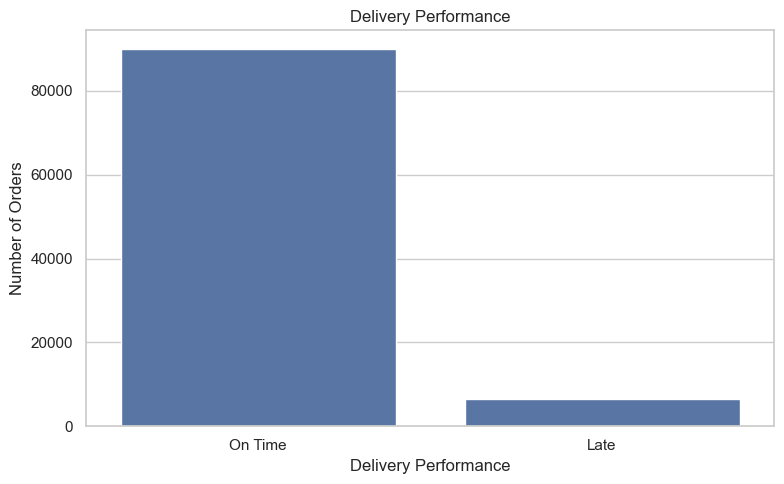

In [38]:
# Step 2.3.5 — Delivery Performance Visualization

plt.figure(figsize=(8, 5))

sns.countplot(
    data=delivered_orders,
    x="delivery_performance"
)

plt.title("Delivery Performance")
plt.xlabel("Delivery Performance")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## 3. Sales Analysis

### What are we analyzing?

We analyze the sales performance of the e-commerce business using order and order-item data.

### Why are we analyzing it?

Sales analysis helps understand revenue generation, customer spending, sales trends, and the impact of product prices and freight costs.

### Business Questions

- What is the total revenue generated?
- What is the Average Order Value (AOV)?
- How does revenue change month by month?
- How do product price and freight value contribute to sales?

### Expected Output

- Total revenue
- Average Order Value
- Monthly revenue trend
- Price and freight analysis

These results will help identify the major drivers of e-commerce revenue and support future business decisions.

In [39]:
# Step 3.1 — Calculate Total Revenue

total_revenue = order_items["price"].sum()

print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 13,591,643.70


In [40]:
# Step 3.2 — Calculate Average Order Value

order_revenue = (
    order_items.groupby("order_id")["price"]
    .sum()
)

average_order_value = order_revenue.mean()

print(f"Average Order Value: {average_order_value:,.2f}")

Average Order Value: 137.75


In [41]:
# Step 3.3 — Calculate Monthly Revenue

monthly_revenue = (
    order_items
    .merge(
        orders[["order_id", "order_purchase_timestamp"]],
        on="order_id",
        how="left"
    )
    .set_index("order_purchase_timestamp")
    .resample("ME")["price"]
    .sum()
    .reset_index(name="revenue")
)

monthly_revenue.head()

,order_purchase_timestamp,revenue
0,2016-09-30,267.36
1,2016-10-31,49507.66
2,2016-11-30,0.00
3,2016-12-31,10.90
4,2017-01-31,120312.87


In [42]:
# Step 3.4 — Analyze Price and Freight Value

price_freight_summary = order_items[
    ["price", "freight_value"]
].describe().round(2)

price_freight_summary

,price,freight_value
count,112650.00,112650.00
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
25%,39.90,13.08
50%,74.99,16.26
75%,134.90,21.15
max,6735.00,409.68


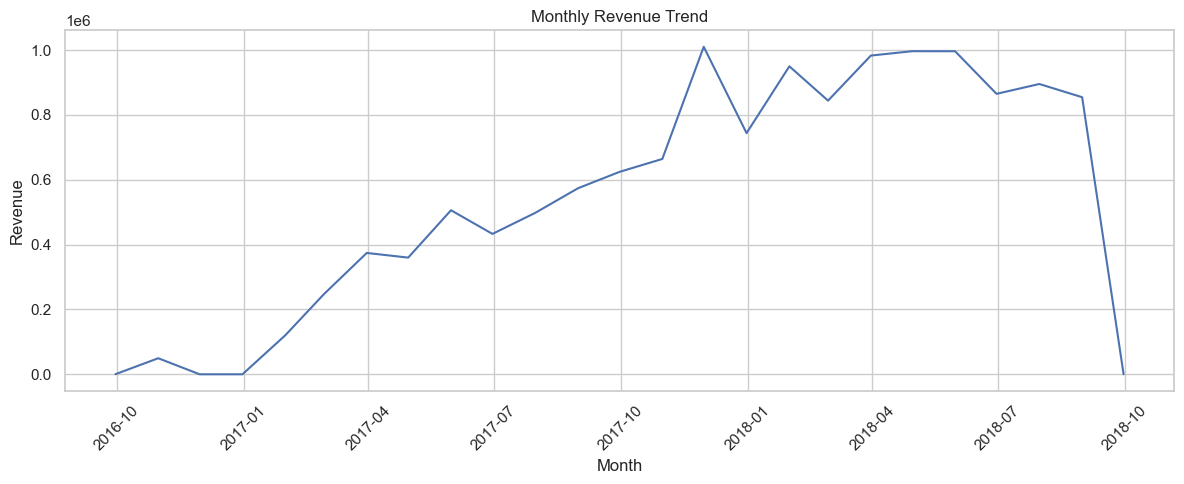

In [43]:
# Step 3.5 — Visualize Monthly Revenue

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["order_purchase_timestamp"],
    monthly_revenue["revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
# Step 3.6 — Visualize Price and Freight Value

price_freight_summary.T

,count,mean,std,min,25%,50%,75%,max
price,112650.0,120.65,183.63,0.85,39.90,74.99,134.90,6735.00
freight_value,112650.0,19.99,15.81,0.00,13.08,16.26,21.15,409.68


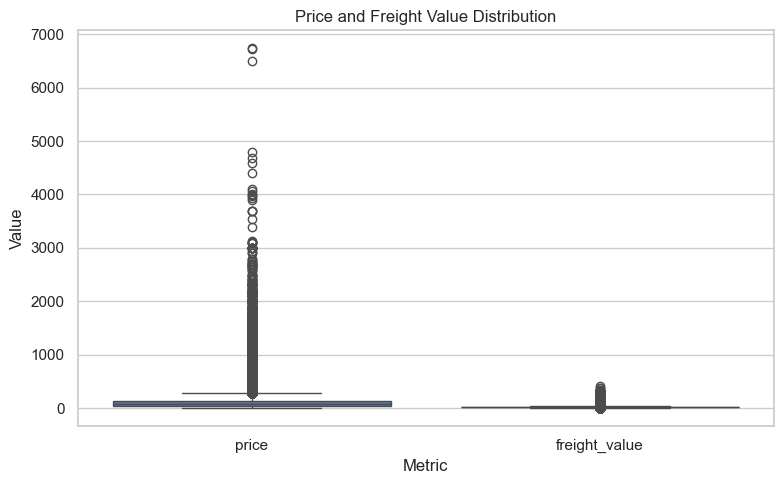

In [45]:
# Step 3.6 — Visualize Price and Freight Value

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=order_items[["price", "freight_value"]]
)

plt.title("Price and Freight Value Distribution")
plt.xlabel("Metric")
plt.ylabel("Value")

plt.tight_layout()
plt.show()